In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def fft1d(x):
    """
    1D Fast Fourier Transform using radix-2 Cooley-Tukey algorithm.
    Input length must be a power of 2.
    """
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x.copy()
    if N & (N - 1):
        raise ValueError("Length of input must be a power of 2")
    X_even = fft1d(x[::2])
    X_odd = fft1d(x[1::2])
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)
    X = np.zeros(N, dtype=complex)
    X[:N//2] = X_even + W * X_odd
    X[N//2:] = X_even - W * X_odd
    return X

def ifft1d(X):
    """
    1D inverse FFT using the conjugate property of the standard FFT.
    """
    X = np.asarray(X, dtype=complex)
    N = len(X)
    return np.conj(fft1d(np.conj(X))) / N

def fft2d(image):
    """
    2D FFT computed sequentially across rows and then columns via 1D FFT.
    """
    image = np.asarray(image, dtype=complex)
    rows, cols = image.shape
    temp = np.zeros((rows, cols), dtype=complex)
    for i in range(rows):
        temp[i, :] = fft1d(image[i, :])
    result = np.zeros((rows, cols), dtype=complex)
    for j in range(cols):
        result[:, j] = fft1d(temp[:, j])
    return result

def ifft2d(F):
    """
    2D inverse FFT computed sequentially across rows and then columns.
    """
    F = np.asarray(F, dtype=complex)
    rows, cols = F.shape
    temp = np.zeros((rows, cols), dtype=complex)
    for i in range(rows):
        temp[i, :] = ifft1d(F[i, :])
    result = np.zeros((rows, cols), dtype=complex)
    for j in range(cols):
        result[:, j] = ifft1d(temp[:, j])
    return result

def next_power_of_two(n):
    return 1 if n == 1 else 2 ** int(np.ceil(np.log2(n)))

def pad_to_power_of_two(image):
    rows, cols = image.shape
    new_rows = next_power_of_two(rows)
    new_cols = next_power_of_two(cols)
    padded = np.zeros((new_rows, new_cols), dtype=float)
    padded[:rows, :cols] = image
    return padded

### Part (a): Load Image and Plot Fourier Spectrum

Image shape: (1023, 767)
Padded shape: (1024, 1024)


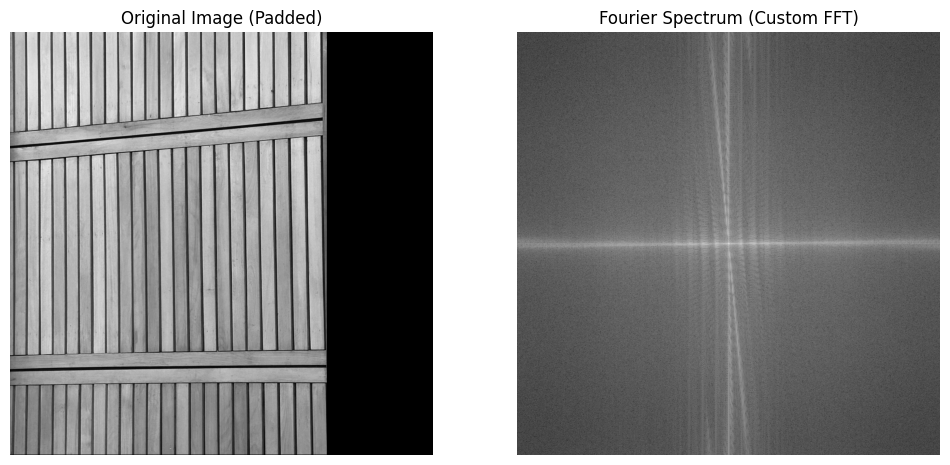

In [8]:
# Load image and convert to grayscale
filename = "img.png"
img = Image.open(filename).convert('L')

# Resize the image such that the longest dimension does not exceed 1024 pixels
max_size = 1024
scale = min(1.0, max_size / max(img.size))
new_size = (
    int(img.size[0] * scale),
    int(img.size[1] * scale)
)
img = img.resize(new_size)

# Convert image to double-precision floating-point format
image = np.asarray(img, dtype=np.float64)

print("Image shape:", image.shape)

# Pad image to the nearest power of two to satisfy the custom FFT constraint
image_padded = pad_to_power_of_two(image)
padded_rows, padded_cols = image_padded.shape
print("Padded shape:", image_padded.shape)

# Compute the 2D Fourier transform
F_custom = fft2d(image_padded)

# Shift the zero-frequency component to the center of the spectrum for visualization
F_shifted = np.fft.fftshift(F_custom)

def spectrum(F):
    return np.log1p(np.abs(F))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_padded, cmap='gray')
plt.title("Original Image (Padded)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(spectrum(F_shifted), cmap='gray')
plt.title("Fourier Spectrum (Custom FFT)")
plt.axis("off")

plt.show()

### Part (b): Resampling and Aliasing

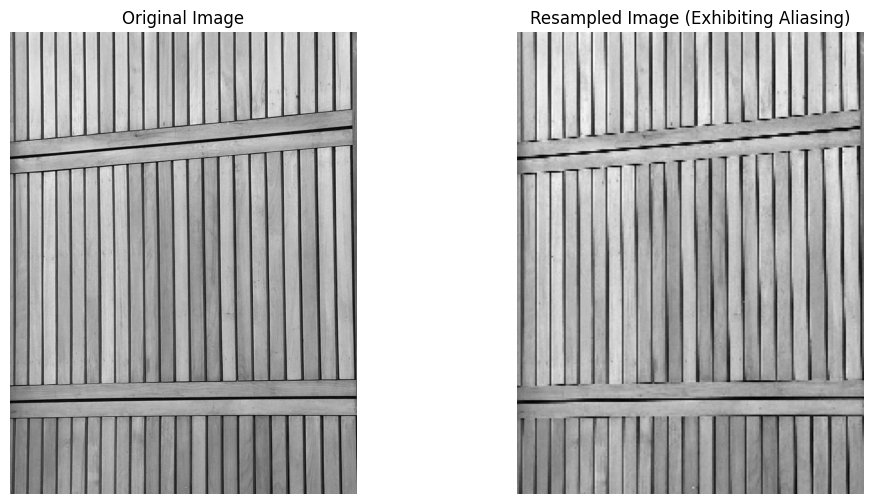

In [9]:
# Define a scale factor that intentionally induces aliasing (sub-Nyquist sampling)
scale_factor = 0.25

# Resample using basic nearest-neighbor subsampling to demonstrate aliasing effects
resampled_image = image[::int(1/scale_factor), ::int(1/scale_factor)]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resampled_image, cmap='gray')
plt.title("Resampled Image (Exhibiting Aliasing)")
plt.axis("off")

plt.show()

### Part (c): Anti-aliasing with Low-Pass Filter

Mathematically, subsampling an image by a factor of $M$ reduces the Nyquist frequency to $f_s / (2M)$. To prevent aliasing, signal frequencies exceeding this new Nyquist limit must be attenuated prior to subsampling. Consequently, the ideal low-pass filter (LPF) $H(u,v)$ in the frequency domain is defined as a 2D rectangular function:

$H(u,v) = 1$ if $|u| \le u_{max}$ and $|v| \le v_{max}$
$H(u,v) = 0$ otherwise

where $u_{max}$ and $v_{max}$ represent the strict Nyquist limits for the vertical and horizontal spatial frequencies, respectively.

For separable Butterworth low-pass filters of order $n$, the transfer function is defined as:
$H_B(u,v) = \frac{1}{1 + (u/u_0)^{2n}} \times \frac{1}{1 + (v/v_0)^{2n}}$


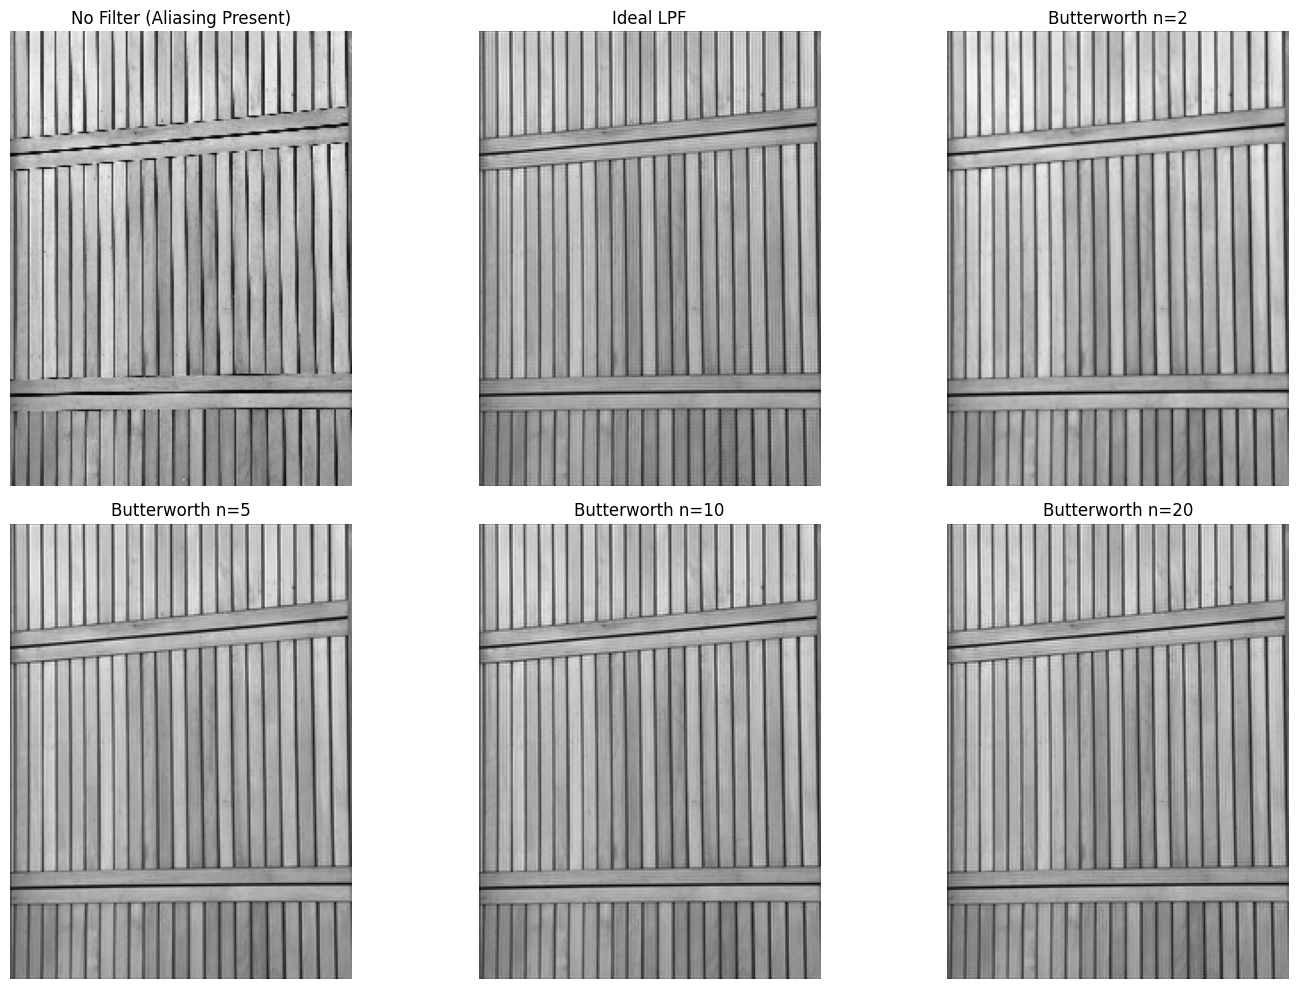

In [10]:
# Shift the computed spectrum to center the zero-frequency component
F_custom_shifted = np.fft.fftshift(F_custom)

# Define the center coordinates of the frequency domain
crow, ccol = padded_rows // 2, padded_cols // 2

# Establish cutoff frequencies proportional to the downsampling scale factor
u0 = crow * scale_factor
v0 = ccol * scale_factor

# Construct the ideal rectangular low-pass filter (LPF)
H_ideal = np.zeros((padded_rows, padded_cols), dtype=float)
u_idx = np.arange(padded_rows) - crow
v_idx = np.arange(padded_cols) - ccol
U, V = np.meshgrid(v_idx, u_idx)

H_ideal[(np.abs(U) <= v0) & (np.abs(V) <= u0)] = 1.0

# Apply the ideal LPF in the frequency domain
F_ideal_shifted = F_custom_shifted * H_ideal
F_ideal = np.fft.ifftshift(F_ideal_shifted)

# Transform back to the spatial domain using inverse custom FFT
img_ideal_lpf_padded = np.real(ifft2d(F_ideal))

# Crop the padded regions to restore original dimensions
img_ideal_lpf = img_ideal_lpf_padded[:image.shape[0], :image.shape[1]]
resampled_ideal = img_ideal_lpf[::int(1/scale_factor), ::int(1/scale_factor)]

# Define Separable Butterworth Filter logic
def butterworth_lpf(U, V, u0, v0, n):
    Hu = 1.0 / (1.0 + (np.abs(V) / v0)**(2 * n))
    Hv = 1.0 / (1.0 + (np.abs(U) / u0)**(2 * n))
    return Hu * Hv

orders = [2, 5, 10, 20]
filtered_images = []

for n in orders:
    H_bw = butterworth_lpf(U, V, u0, v0, n)
    F_bw_shifted = F_custom_shifted * H_bw
    F_bw = np.fft.ifftshift(F_bw_shifted)
    
    img_bw_padded = np.real(ifft2d(F_bw))
    img_bw = img_bw_padded[:image.shape[0], :image.shape[1]]
    
    resampled_bw = img_bw[::int(1/scale_factor), ::int(1/scale_factor)]
    filtered_images.append((n, resampled_bw))

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(resampled_image, cmap='gray')
plt.title("No Filter (Aliasing Present)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resampled_ideal, cmap='gray')
plt.title("Ideal LPF")
plt.axis("off")

for i, (n, img_bw) in enumerate(filtered_images):
    plt.subplot(2, 3, 3 + i)
    plt.imshow(img_bw, cmap='gray')
    plt.title(f"Butterworth n={n}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Part (d): Notch-Reject Filter

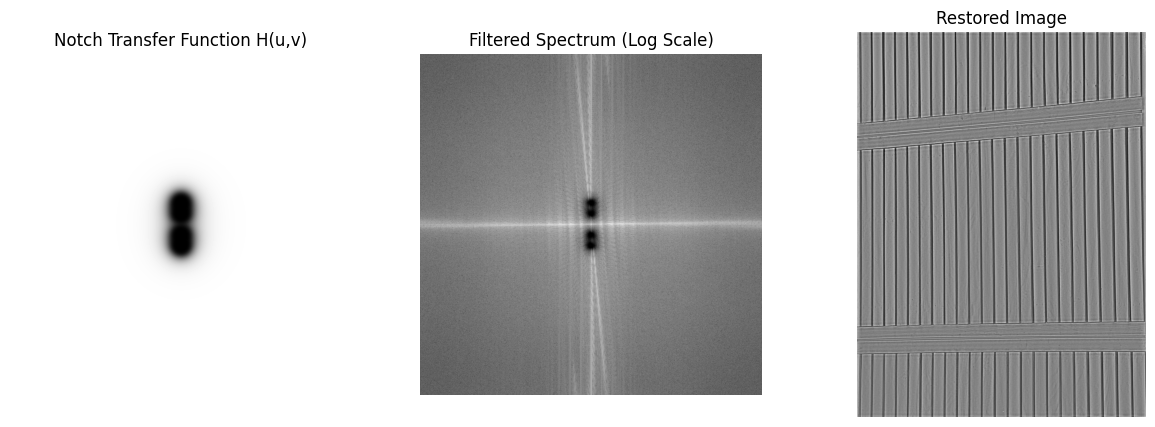

In [11]:
# To preserve original spatial dimensions while suppressing specific periodic noise patterns,
# a notch-reject filter is designed. The filter targets distinct impulsive peaks in the frequency domain.

# Compute the magnitude spectrum and isolate the DC component to avoid unintended suppression
spectrum_mag = np.abs(F_custom_shifted)
spectrum_mag[crow-10:crow+10, ccol-10:ccol+10] = 0 

# Extract indices of the highest magnitude peaks corresponding to periodic noise
flat_indices = np.argsort(spectrum_mag.flatten())[::-1]

notch_centers = []
for idx in flat_indices:
    r, c = np.unravel_index(idx, spectrum_mag.shape)
    # Ensure sufficient spatial separation between identified notch centers
    if all(np.sqrt((r-cr)**2 + (c-cc)**2) > 30 for cr, cc in notch_centers):
        notch_centers.append((r, c))
        # Enforce conjugate symmetry for real-valued spatial outputs
        notch_centers.append((padded_rows - r, padded_cols - c))
    if len(notch_centers) >= 4:
        break

def notch_reject_filter(shape, centers, D0=15, n=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows) - crow
    v = np.arange(cols) - ccol
    U, V = np.meshgrid(v, u)
    
    H = np.ones((rows, cols), dtype=float)
    for r, c in centers:
        u_k, v_k = r - crow, c - ccol
        D_k = np.sqrt((V - v_k)**2 + (U - u_k)**2)
        D_min_k = np.sqrt((V + v_k)**2 + (U + u_k)**2)
        
        # Prevent division by zero singularities
        D_k[D_k == 0] = 1e-5
        D_min_k[D_min_k == 0] = 1e-5
        
        H *= (1.0 / (1.0 + (D0 / D_k)**(2*n))) * (1.0 / (1.0 + (D0 / D_min_k)**(2*n)))
    return H

H_notch = notch_reject_filter(image_padded.shape, notch_centers, D0=30, n=2)

# Apply the designed notch filter in the frequency domain
F_notch_shifted = F_custom_shifted * H_notch
F_notch = np.fft.ifftshift(F_notch_shifted)

img_notch_padded = np.real(ifft2d(F_notch))
img_notch = img_notch_padded[:image.shape[0], :image.shape[1]]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(H_notch, cmap='gray')
plt.title("Notch Transfer Function H(u,v)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(spectrum(F_notch_shifted), cmap='gray')
plt.title("Filtered Spectrum (Log Scale)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_notch, cmap='gray')
plt.title("Restored Image")
plt.axis("off")

plt.show()

### Part (e): Optimum Notch Filtering

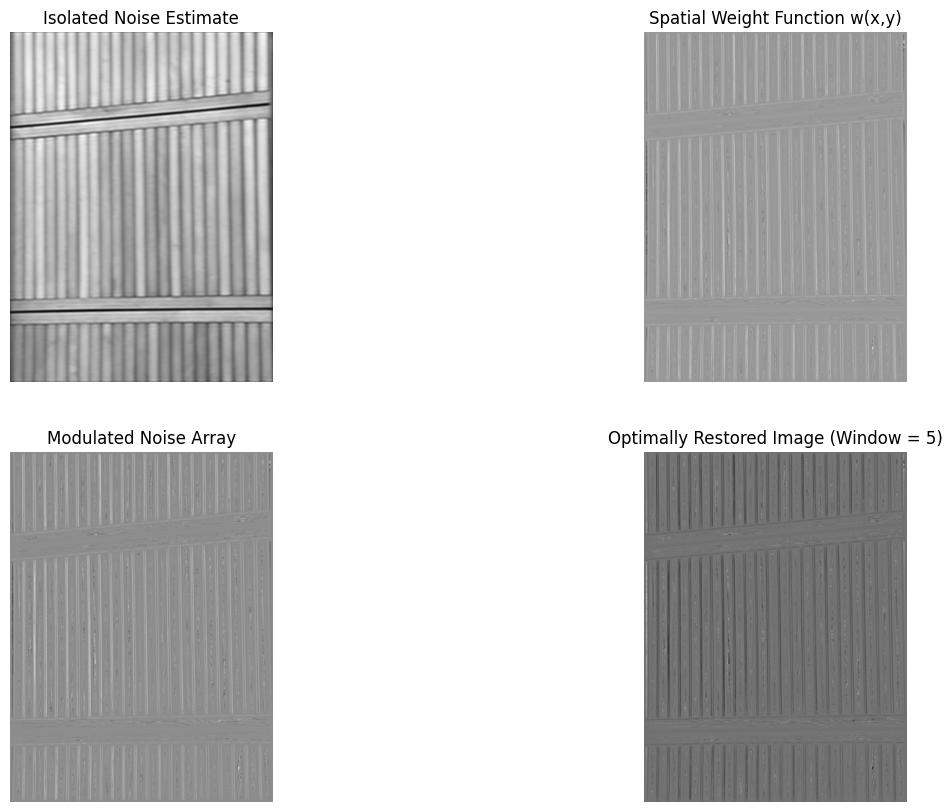

In [12]:
# Optimum notch filtering assumes that the periodic noise is additive.
# The technique extracts a baseline noise estimate from the notch regions and subtracts a spatially modulated 
# variant from the original image, minimizing local image degradation.

# Isolate the interference pattern using a complementary Notch Pass Filter
H_notch_pass = 1.0 - H_notch
F_noise_shifted = F_custom_shifted * H_notch_pass
F_noise = np.fft.ifftshift(F_noise_shifted)

noise_est_padded = np.real(ifft2d(F_noise))
noise_est = noise_est_padded[:image.shape[0], :image.shape[1]]

# Define a spatial neighborhood dimension for local variance and covariance computation
neighborhood_size = 5

def box_filter(img, size):
    # Construct a normalized uniform kernel for spatial mean estimation
    kernel = np.ones((size, size)) / (size * size)
    kh, kw = size, size
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output

# Compute the local mean values for the noise estimate and the original image
local_mean_noise = box_filter(noise_est, neighborhood_size)
local_mean_img = box_filter(image, neighborhood_size)

# Calculate the local variance of the noise and the local covariance between the image and the noise
noise_var = box_filter(noise_est**2, neighborhood_size) - local_mean_noise**2
cov_img_noise = box_filter(image * noise_est, neighborhood_size) - local_mean_img * local_mean_noise

# Compute the spatially adaptive weight function w(x,y)
# A small constant is added to the denominator to maintain numerical stability
w = cov_img_noise / (noise_var + 1e-6)

# Deduct the modulated noise estimate from the original image
img_restored = image - w * noise_est

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(noise_est, cmap='gray')
plt.title("Isolated Noise Estimate")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(w, cmap='gray')
plt.title("Spatial Weight Function w(x,y)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(w * noise_est, cmap='gray')
plt.title("Modulated Noise Array")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_restored, cmap='gray')
plt.title(f"Optimally Restored Image (Window = {neighborhood_size})")
plt.axis("off")

plt.show()